## 2D registration example:

This notebook develops a 2d registration algorithm for images with cubic images

In [1]:
# Example usage
import numpy as np
import plot_library as pl
import matplotlib.pyplot as plt
from scipy.ndimage import sobel
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize


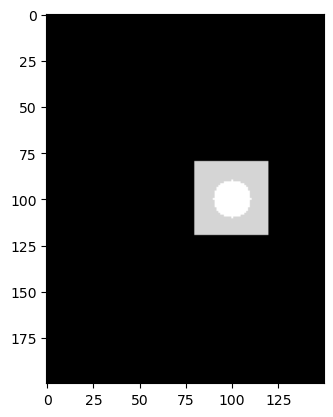

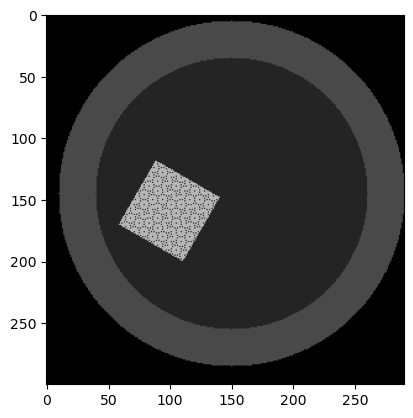

In [2]:
image_size = (200, 150)
circles = []  # (x, y, radius)
squares = [(100, 100, 40, 0)]  # (x, y, size, angle)
im1 = pl.create_phantom_image(image_size, circles, squares)

circles = [(100,100,10)]  # (x, y, radius)
squares = []  # (x, y, size, angle)
im2 = pl.create_phantom_image(image_size, circles, squares)*0.2
recon1 = im1+im2

image_size = (300,290)
circles = []  # (x, y, radius)
squares = [(100, 160, 60, 30)]  # (x, y, size, angle)
im1 = pl.create_phantom_image(image_size, circles, squares)*0.4
circles = [(150,145,140)]  # (x, y, radius)
squares = []  # (x, y, size, angle)
im2 = pl.create_phantom_image(image_size, circles, squares)*0.2
circles = [(150,145,110)]  # (x, y, radius)
squares = []  # (x, y, size, angle)
im3 = pl.create_phantom_image(image_size, circles, squares)*(-0.1)
recon2 = im1+im2+im3


# To visualize the generated phantom image (optional)
plt.imshow(recon1, cmap='gray')
plt.clim([0,1.2])
plt.show()

plt.imshow(recon2, cmap='gray')
plt.clim([0,0.7])
plt.show()

In [3]:
r_r1, c_r1 = np.shape(recon1)
r_r2, c_r2 = np.shape(recon2)
target_shape = (max(r_r1, r_r2), max(c_r1, c_r2))  # Desired dimensions

recon1_ = pl.pad_matrix(recon1, target_shape)
recon2_ = pl.pad_matrix(recon2, target_shape)

sigma = 10  # Standard deviation for Gaussian kernel
recon1_ = gaussian_filter(recon1_, sigma=sigma)
recon2_ = gaussian_filter(recon2_, sigma=sigma)


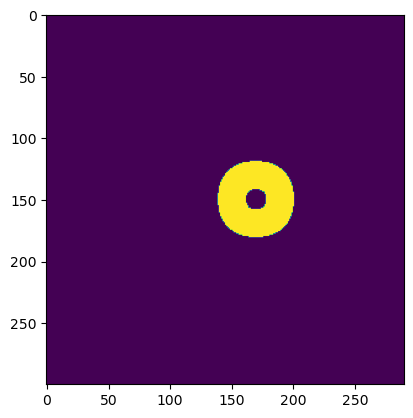

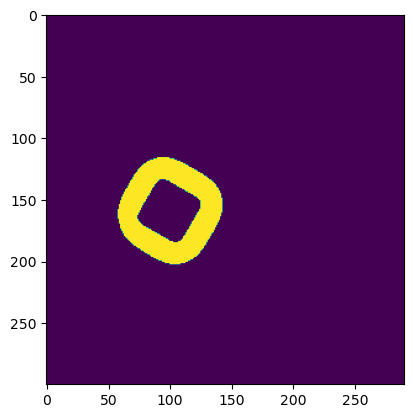

In [53]:
dx_r1 = sobel(recon1_, axis=0)  # Sobel filter in the x direction
dy_r1 = sobel(recon1_, axis=1)  # Sobel filter in the y direction

dx_r2 = sobel(recon2_, axis=0)  # Sobel filter in the x direction
dy_r2 = sobel(recon2_, axis=1)  # Sobel filter in the y direction

# Combine the two gradients
E1 = dx_r1**2 + dy_r1**2
E2 = dx_r2**2 + dy_r2**2

E1 = (E1>0.03)*1.0
E2 = (E2>0.005)*1.0

plt.imshow(E1)
plt.show()
plt.imshow(E2)
plt.show()


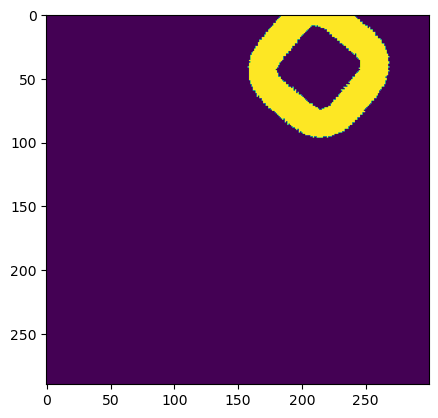

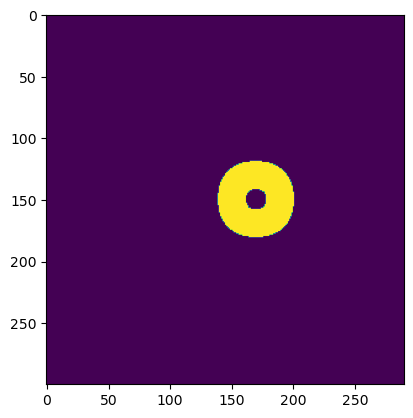

In [54]:
x,y = pl.transform_grid(target_shape[0], target_shape[1], 0.8, 20, (10,10))
x,y = np.round(x).astype(int), np.round(y).astype(int)
x,y = np.clip(x,a_min = 0,a_max = target_shape[0]-1), np.clip(y, a_min = 0, a_max = target_shape[1]-1)
N_rows, N_cols = np.shape(E1)
plt.imshow(E2[x,y])
plt.show()
plt.imshow(E1)
plt.show()

In [74]:
def loss(params, E1, E2):
    x0, y0, theta, d, k = params
    N_rows, N_cols = np.shape(E1)
    x,y = pl.transform_grid(N_cols, N_rows, d, theta, (x0,y0))
    x,y = np.round(x).astype(int), np.round(y).astype(int)
    x,y = np.clip(x,a_min = 0,a_max = N_rows-1), np.clip(y, a_min = 0, a_max = N_cols-1)
    temp = E2[x,y]
    diff = E1 - temp
    print(np.sum(diff*diff))
    return np.sum(diff*diff)

In [75]:
initial_guess = [0, 0, 0, 1, 1]
result = minimize(loss, initial_guess, args=(E1,E2,), method='Nelder-Mead',
            bounds=[(-N_cols, N_cols), (-N_rows, N_rows), (0,360), (0.3,3), (0.3,3)],tol=1e-10)
transformation_pars = result.x
print(transformation_pars)

5192.0
5192.0
5192.0
5192.0
5630.0
5192.0
5190.0
5403.0
5133.0
5110.0
5137.0
5171.0
5241.0
5099.0
5280.0
5138.0
5159.0
5235.0
5150.0
5186.0
5099.0
5106.0
5112.0
5162.0
5076.0
5089.0
5221.0
5147.0
5136.0
5132.0
5132.0
5168.0
5136.0
5119.0
5171.0
5082.0
5130.0
5108.0
5156.0
5132.0
5080.0
5140.0
5084.0
5087.0
5144.0
5113.0
5077.0
5136.0
5140.0
5076.0
5080.0
5071.0
5071.0
5136.0
5130.0
5099.0
5093.0
5071.0
5080.0
5077.0
5071.0
5076.0
5075.0
5091.0
5075.0
5080.0
5071.0
5076.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0
5071.0

In [76]:
x0, y0, theta, d, k = 0, 0, 0, 1, 1
params = (x0,y0,theta,d,k)
params = transformation_pars
loss(params, E1,E2)
print(transformation_pars)


5071.0
[2.30800894e-04 1.76143992e-04 5.81276402e-05 9.73804930e-01
 9.56728610e-01]


1030.0
1030.0


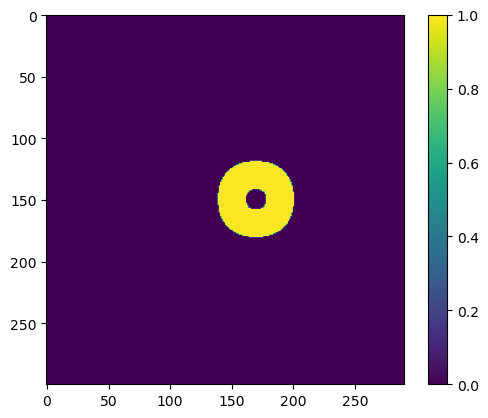

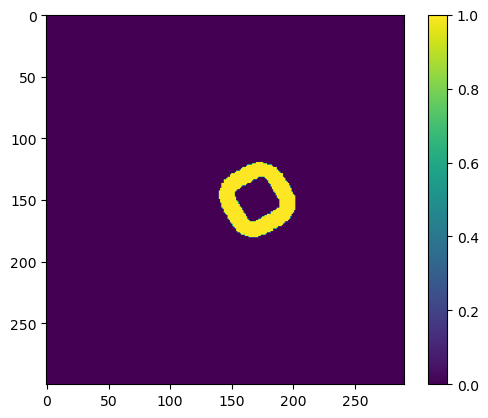

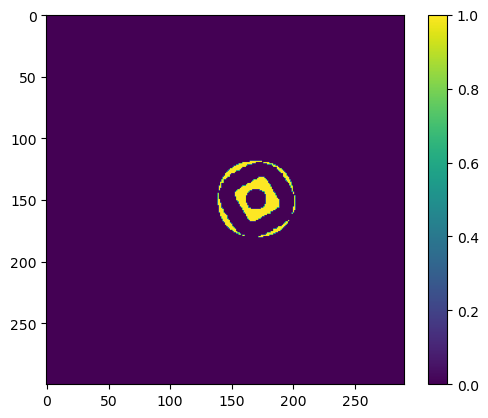

In [ ]:
(x0,y0,theta,d,k) = transformation_pars
(x0,y0,theta,d,k) = (-80,-110, 0, 1.4,1.5)
print(loss((x0,y0,theta,d,k), E1,E2))
x,y = pl.transform_grid(N_cols, N_rows, d, theta, (x0,y0))
x,y = np.round(x).astype(int), np.round(y).astype(int)
x,y = np.clip(x,a_min = 0,a_max = N_rows-1), np.clip(y, a_min = 0, a_max = N_cols-1)
plt.imshow(E1)
plt.colorbar()
plt.show()
plt.imshow(E2[x,y])
plt.colorbar()
plt.show()

plt.imshow((E2[x,y]-E1)**2)
plt.colorbar()
plt.show()

0.00024295822511867006